# Project 10 -- Lukas Anell

## Question 1

In [2]:
library(ggplot2)
library(dplyr)

In [6]:
myDF <- read.table("/anvil/projects/tdm/data/ssa/yob2006.txt", sep = ",", header = FALSE)
the_1997 <- read.table("/anvil/projects/tdm/data/ssa/yob1997.txt", sep = ",", header = FALSE)

In [7]:
colnames(myDF) <- c("Name", "Sex", "Counts")
colnames(the_1997) <- c("Name", "Sex", "Counts")

In [24]:
alan_2006 <- subset(myDF, Name == "Alan")
eric_2006 <- subset(myDF, Name == "Eric")
avery_2006 <- subset(myDF, Name == "Avery")

alan_1997 <- subset(the_1997, Name == "Alan")
eric_1997 <- subset(the_1997, Name == "Eric")
avery_1997 <- subset(the_1997, Name == "Avery")

In [33]:
head(the_1997)
head(myDF)

,Name,Sex,Counts
,<chr>,<chr>,<int>
1,Emily,F,25735
2,Jessica,F,21045
3,Ashley,F,20896
4,Sarah,F,20716
5,Hannah,F,20596
6,Samantha,F,20170


,Name,Sex,Counts
,<chr>,<chr>,<int>
1,Emily,F,21411
2,Emma,F,19128
3,Madison,F,18635
4,Isabella,F,18231
5,Ava,F,16941
6,Abigail,F,15633


In [31]:
summarize_name_counts <- function(df, year_label) {
  df %>%
    filter(Name %in% c("Alan", "Eric", "Avery")) %>%
    group_by(Name, Sex) %>%
    summarize(Total = sum(Counts), .groups = "drop") %>%
    mutate(Year = year_label) %>%
    select(Year, Name, Sex, Total)
}

In [32]:
summary_2006 <- summarize_name_counts(myDF, "2006")
summary_1997 <- summarize_name_counts(the_1997, "1997")

combined_summary <- bind_rows(summary_1997, summary_2006) %>%
  arrange(Name, Year, Sex)

combined_summary

Year,Name,Sex,Total
<chr>,<chr>,<chr>,<int>
1997,Alan,F,7
1997,Alan,M,2177
2006,Alan,F,6
2006,Alan,M,3475
1997,Avery,F,937
1997,Avery,M,1173
2006,Avery,F,5254
2006,Avery,M,1794
1997,Eric,F,37


In [34]:
get_top_20 <- function(df) {
  df %>%
    group_by(Name) %>%
    summarise(Total = sum(Counts), .groups = "drop") %>%
    arrange(desc(Total)) %>%
    slice_head(n = 20)
}

In [35]:
top20_1997 <- get_top_20(the_1997)
top20_2006 <- get_top_20(myDF)

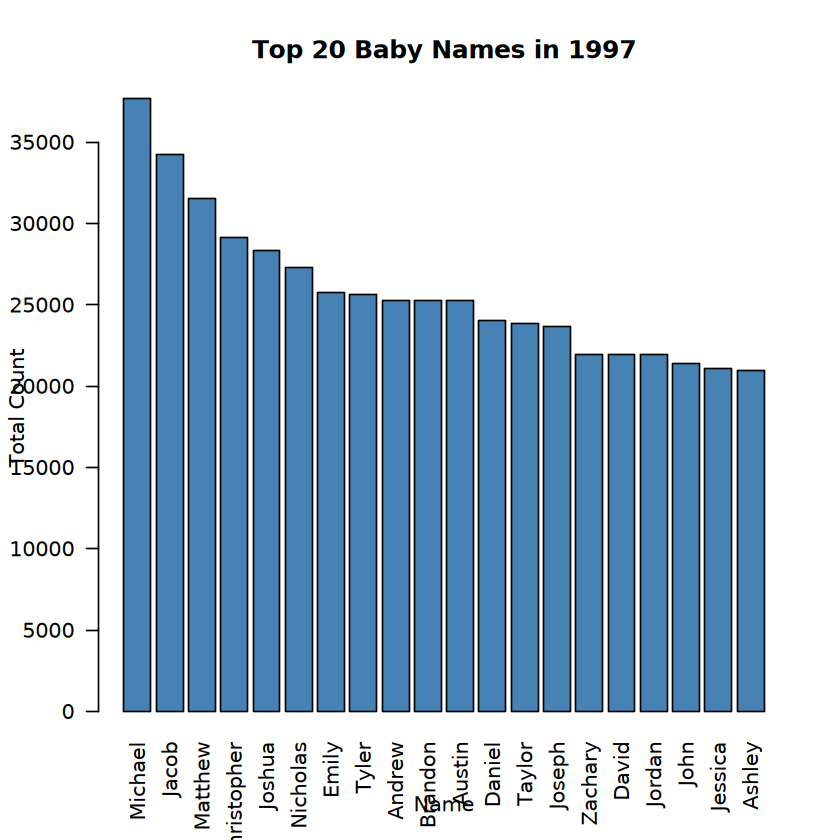

In [50]:
barplot(
    height = top20_1997$Total,
    names.arg = top20_1997$Name,
    las = 2,
    main = "Top 20 Baby Names in 1997",
    xlab = "Name",
    ylab = "Total Count",
    col = "steelblue"
)

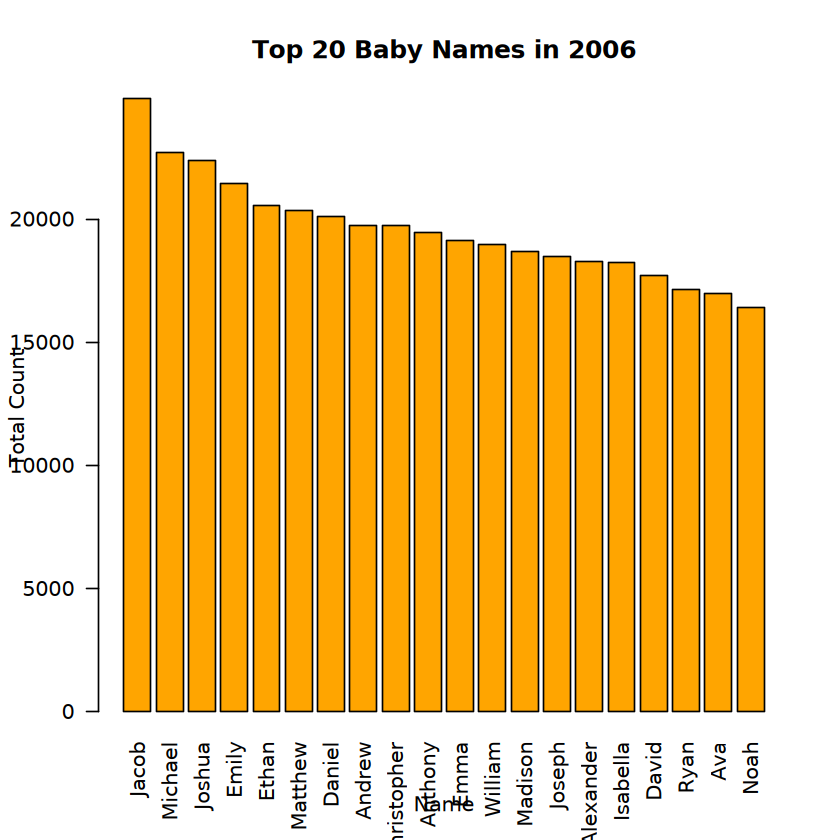

In [51]:
barplot(
    height = top20_2006$Total,
    names.arg = top20_2006$Name,
    las = 2,
    main = "Top 20 Baby Names in 2006",
    xlab = "Name",
    ylab = "Total Count",
    col = "orange"
)

In [52]:
top20_1997 <- top20_1997 %>%
  mutate(Name = factor(Name, levels = rev(Name)))

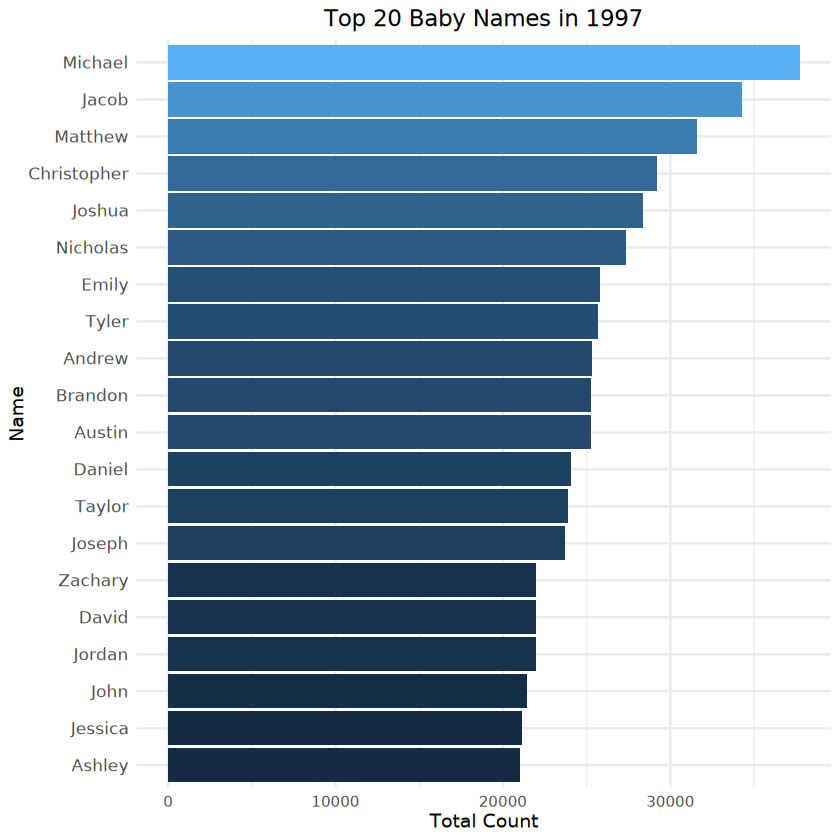

In [56]:
p_1997 <- ggplot(
    top20_1997,
    aes(x = Name, y = Total, fill = Total)
) + 
    geom_col(show.legend = FALSE) +
    coord_flip() +
    labs(
        title = "Top 20 Baby Names in 1997",
        x = "Name",
        y = "Total Count"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5),
        axis.text.y = element_text(size = 10)
    )

p_1997

In [58]:
top20_2006 <- top20_2006 %>%
  mutate(Name = factor(Name, levels = rev(Name)))

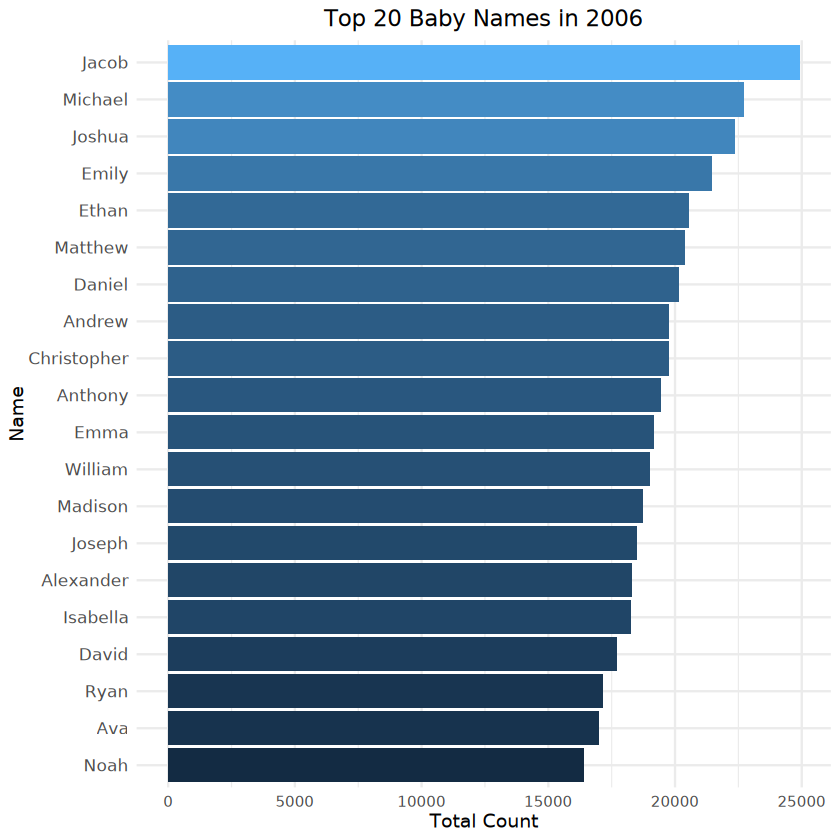

In [61]:
p_2006 <- ggplot(
    top20_2006,
    aes(x = Name, y = Total, fill = Total)
) + 
    geom_col(show.legend = FALSE) +
    coord_flip() +
    labs(
        title = "Top 20 Baby Names in 2006",
        x = "Name",
        y = "Total Count"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5),
        axis.text.y = element_text(size = 10)
    )

p_2006

When researching dplyr functions, because I think they were present in Project 5, which I had to scrap after losing all my work, I found that `summarize()` can also be referred to as [summarise()](https://dplyr.tidyverse.org/reference/summarise.html), like the British English spelling. I had to research this because I couldn't remember how to use it.
I also found the `bind_rows` function very useful when combining the data into one table, [link](https://dplyr.tidyverse.org/reference/bind_rows.html).
I like the amount of customization I can get from ggplot2, I got info for how to use it from [here](https://r-graph-gallery.com/218-basic-barplots-with-ggplot2.html). I also decided to flip the axes because I thought the labels are easier to read that way.

1.1: Out of the selected names, Alan has gotten more popular overall, Avery has gotten slightly more popular among men but a lot more popular among women, and Eric has gone down in popularity a lot, but much much more in men.

1.2: See 50-59.

1.3: I found a nice guide/cheatsheet with a lot of useful information about ggplot2 online, and I just added what I thought looked cool and what was necessary. As I stated above, I decided to flip the graph to make it easier to read the names. I also thought the gradient on the bars was pretty cool, and was easy to add with `fill = Total`.

## Question 2

In [82]:
df_grouped <- myDF %>%
# the first_letter = each name, start at position 1 and end at position 1 (of the name)(meaning first letter)
  mutate(first_letter = substr(Name, 1, 1)) %>%
# group by each first_letter
  group_by(first_letter) %>%
# create smaller dataset to aggregate the groups
# calculate the sum of the Counts (of the names) of each first letter
  summarize(total_count = sum(Counts))

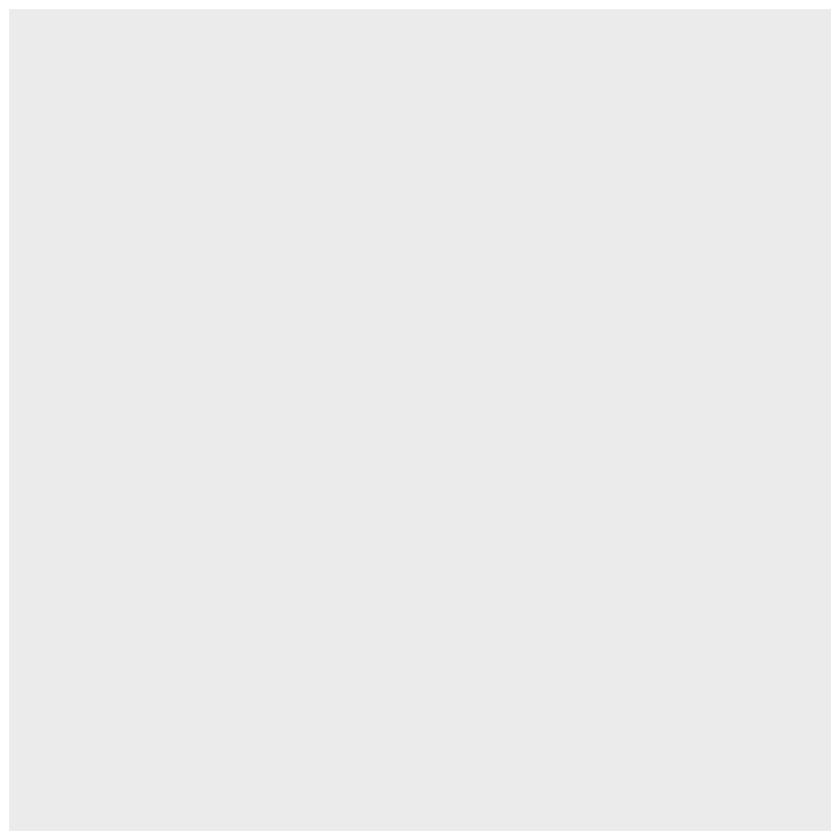

In [83]:
ggplot()

In [84]:
letters_df <- data.frame(first_letter = LETTERS, stringsAsFactors = FALSE)

df_grouped <- letters_df %>%
  left_join(df_grouped, by = "first_letter")

df_grouped$total_count[is.na(df_grouped$total_count)] <- 0

df_grouped

first_letter,total_count
<chr>,<dbl>
A,548710
B,174687
C,286526
D,208703
E,222850
F,33023
G,115702
H,94301
I,85057


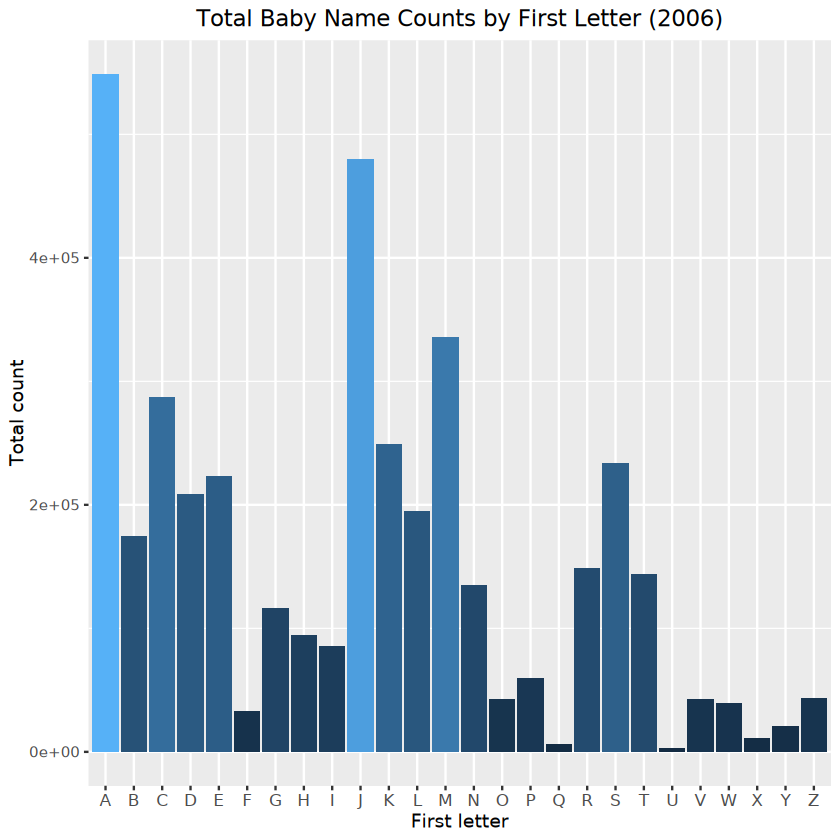

In [85]:
df_grouped <- df_grouped %>%
  mutate(first_letter = factor(first_letter, levels = LETTERS))

p_letters <- ggplot(
    df_grouped,
    aes(x = first_letter, y = total_count, fill = total_count)
) +
    geom_col(show.legend = FALSE) +
    labs(
        title = "Total Baby Name Counts by First Letter (2006)",
        x = "First letter",
        y = "Total count"
    ) +
    theme(
        plot.title = element_text(hjust = 0.5),
        axis.text.x = element_text(size = 10)
    )

p_letters

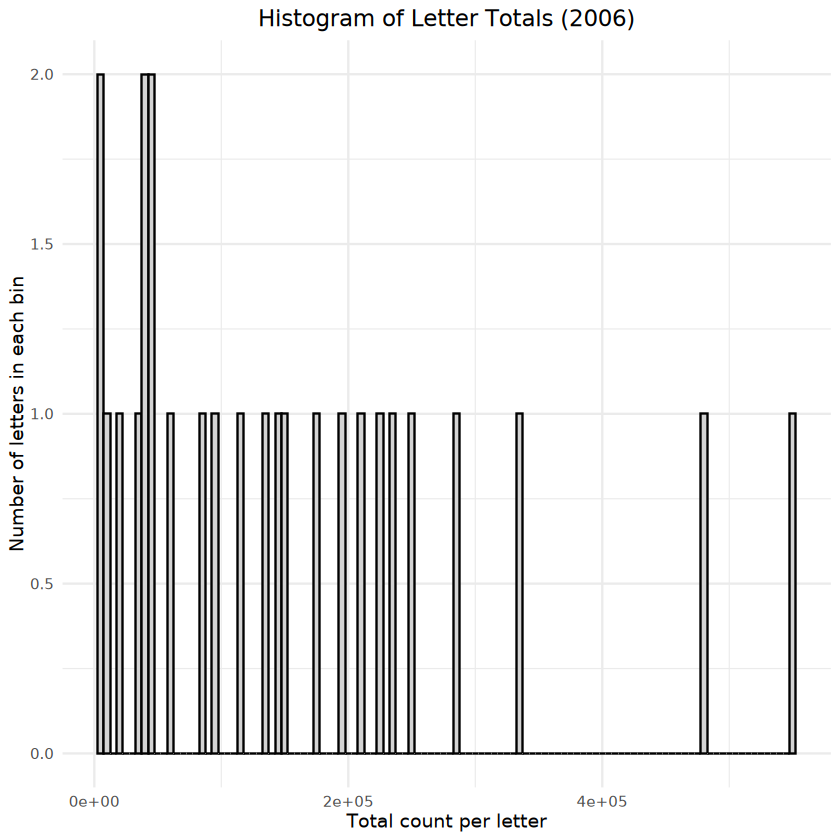

In [86]:
p_hist_bad <- ggplot(
    df_grouped,
    aes(x = total_count)
) +
    geom_histogram(
        binwidth = 5000,
        color = "black",
        fill = "lightgray"
    ) +
    labs(
        title = "Histogram of Letter Totals (2006)",
        x = "Total count per letter",
        y = "Number of letters in each bin"
    ) +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5))

print(p_hist_bad)

The rest of this question is easy enough, but I'm a bit confused about what this histogram is supposed to represent even after reading the explanation in the instructions. Anyway, I figured out how to use it using https://ggplot2.tidyverse.org/reference/geom_histogram.html, and https://www.sthda.com/english/wiki/ggplot2-histogram-plot-quick-start-guide-r-software-and-data-visualization.

2.1: See 82 & 84.

2.2: See 85. I chose geom_col because it's a lot easier to use with the data we have, as we've already counted the total_count of each first letter, so geom_col would just use those.

2.3: See 86. After looking at the data more after my previous comments, I think I understand it now. It it's basically counting how many letters were counted n times, and will put them in the same bin if they're the same. This doesn't work with this data because we need to see the numbers for each categorie, not the amount of categories per number.

## Question 3

In [92]:
df_grouped_again <- myDF %>%
  mutate(first_letter = substr(Name, 1, 1)) %>%
  group_by(first_letter, Sex) %>%
  summarise(total_count = sum(Counts), .groups = 'drop')

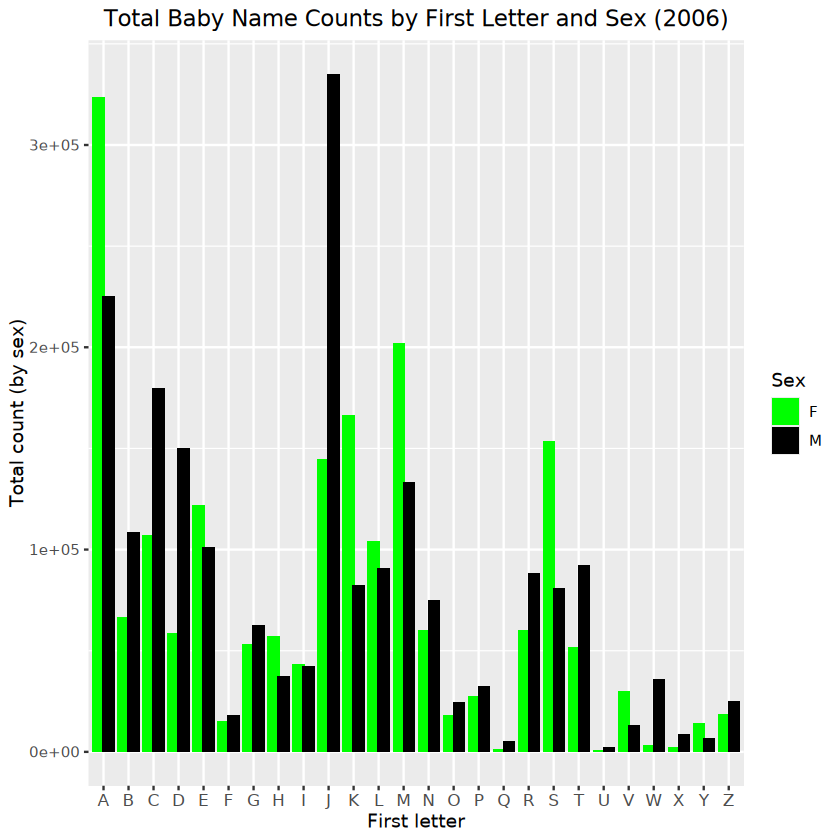

In [101]:
p_distr_names_across_letters <- ggplot(
    df_grouped_again,
    aes(x = first_letter, y = total_count, fill = Sex)
) +
    geom_col(position = position_dodge(width = 0.8)) +
    labs(
        title = "Total Baby Name Counts by First Letter and Sex (2006)",
        x = "First letter",
        y = "Total count (by sex)"
    ) +
      theme(
          plot.title = element_text(hjust = 0.5),
            axis.text.x = element_text(size = 10)
      ) +
    scale_fill_manual(values = c("F" = "green", "M" = "black"))

p_distr_names_across_letters

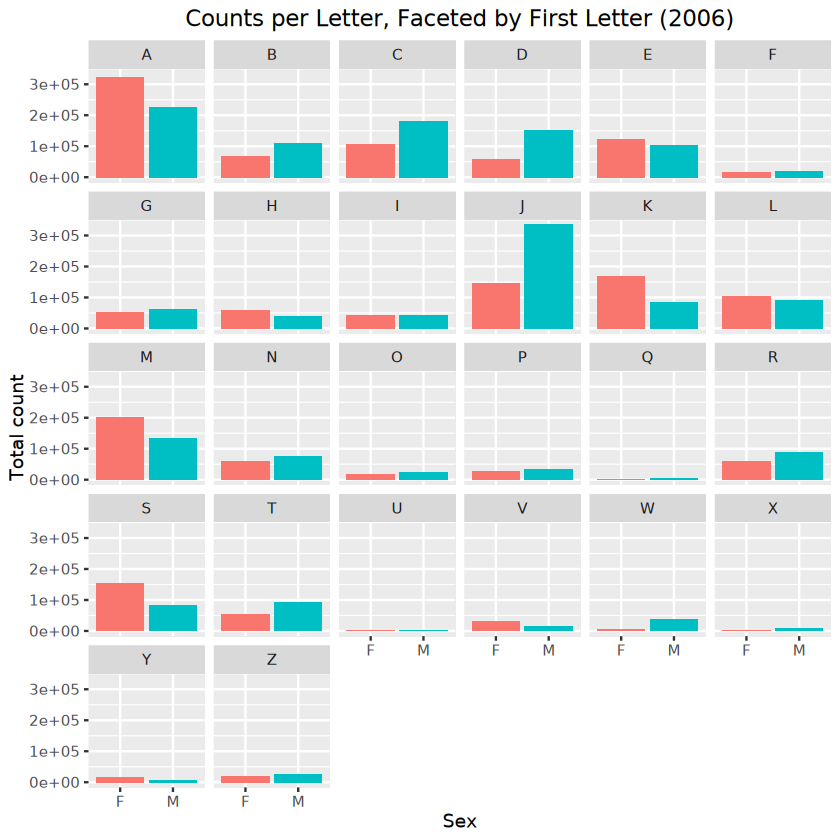

In [118]:
p_facet_by_letter <- ggplot(
    df_grouped_again,
    aes(x = Sex, y = total_count, fill = Sex)
) +
    geom_col(show.legend = FALSE) +
    facet_wrap(~first_letter) +
    labs(
        title = "Counts per Letter, Faceted by First Letter (2006)",
        x = "Sex",
        y = "Total count"
    ) +
    theme(plot.title = element_text(hjust = 0.5))

p_facet_by_letter

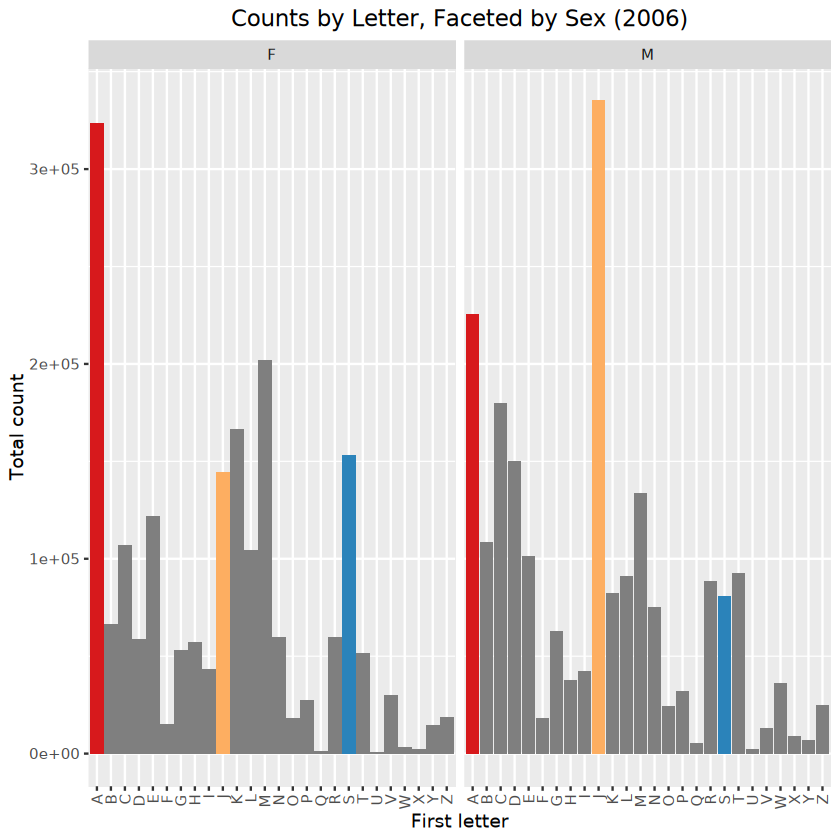

In [122]:
p_facet_by_sex <- ggplot(
    df_grouped_again,
    aes(x = first_letter, y = total_count, fill = first_letter)
) +
    geom_col(show.legend = FALSE) +
    facet_wrap(~Sex) +
    labs(
        title = "Counts by Letter, Faceted by Sex (2006)",
        x = "First letter",
        y = "Total count"
    ) +
    theme(
        plot.title = element_text(hjust = 0.5),
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)
    ) +
    scale_fill_manual(values = c(
        "A" = "#d7191c",
        "J" = "#fdae61",
        "S" = "#2b83ba",
        "Other" = "grey80"
    ))

p_facet_by_sex

Looking at the first barplot, I think it's very interesting how some letters, like A, J, M, and S all have very large margins between Female and Male names' usage of them as a first letter.
The faceted barplot is super cool and makes the data a lot easier to read, I wasn't sure if I was lining up the correct bars on the previous pot. I really like the look of it.
On the second faceted barplot, I was running into an error because I was still faceting by first_letter, so the graph would look really odd. With it correctly, I think it also looks super cool, but I think if could be harder to read then the plot faceted by first_letter.

3.1: See 101.

3.2: See 118 and 119.

3.3: I applied the scale_fill to highlight the A, J, and S counts, as I thought they were interesting in how they differed between males and females. See 119.

## Question 4

In [164]:
zillow = read.csv("/anvil/projects/tdm/data/zillow/State_time_series.csv")
head(zillow)

,Date,RegionName,DaysOnZillow_AllHomes,InventorySeasonallyAdjusted_AllHomes,InventoryRaw_AllHomes,MedianListingPricePerSqft_1Bedroom,MedianListingPricePerSqft_2Bedroom,MedianListingPricePerSqft_3Bedroom,MedianListingPricePerSqft_4Bedroom,MedianListingPricePerSqft_5BedroomOrMore,...,ZHVI_BottomTier,ZHVI_CondoCoop,ZHVI_MiddleTier,ZHVI_SingleFamilyResidence,ZHVI_TopTier,ZRI_AllHomes,ZRI_AllHomesPlusMultifamily,ZriPerSqft_AllHomes,Zri_MultiFamilyResidenceRental,Zri_SingleFamilyResidenceRental
,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>
1,1996-04-30,Alabama,NA,NA,NA,NA,NA,NA,NA,NA,...,45600,99500,79500,79000,140200,NA,NA,NA,NA,NA
2,1996-04-30,Arizona,NA,NA,NA,NA,NA,NA,NA,NA,...,67100,78900,103600,107500,168700,NA,NA,NA,NA,NA
3,1996-04-30,Arkansas,NA,NA,NA,NA,NA,NA,NA,NA,...,38400,70300,64400,64500,115200,NA,NA,NA,NA,NA
4,1996-04-30,California,NA,NA,NA,NA,NA,NA,NA,NA,...,95100,136100,157900,162000,270600,NA,NA,NA,NA,NA
5,1996-04-30,Colorado,NA,NA,NA,NA,NA,NA,NA,NA,...,82700,99400,128100,133600,209300,NA,NA,NA,NA,NA
6,1996-04-30,Connecticut,NA,NA,NA,NA,NA,NA,NA,NA,...,83700,85000,132000,141000,231600,NA,NA,NA,NA,NA


In [165]:
zillow_cleaned <- zillow %>%
  filter(!is.na(DaysOnZillow_AllHomes),
         !is.na(MedianListingPrice_AllHomes),
         !is.na(PctOfHomesDecreasingInValues_AllHomes),
         !is.na(PctOfHomesIncreasingInValues_AllHomes))

NULL

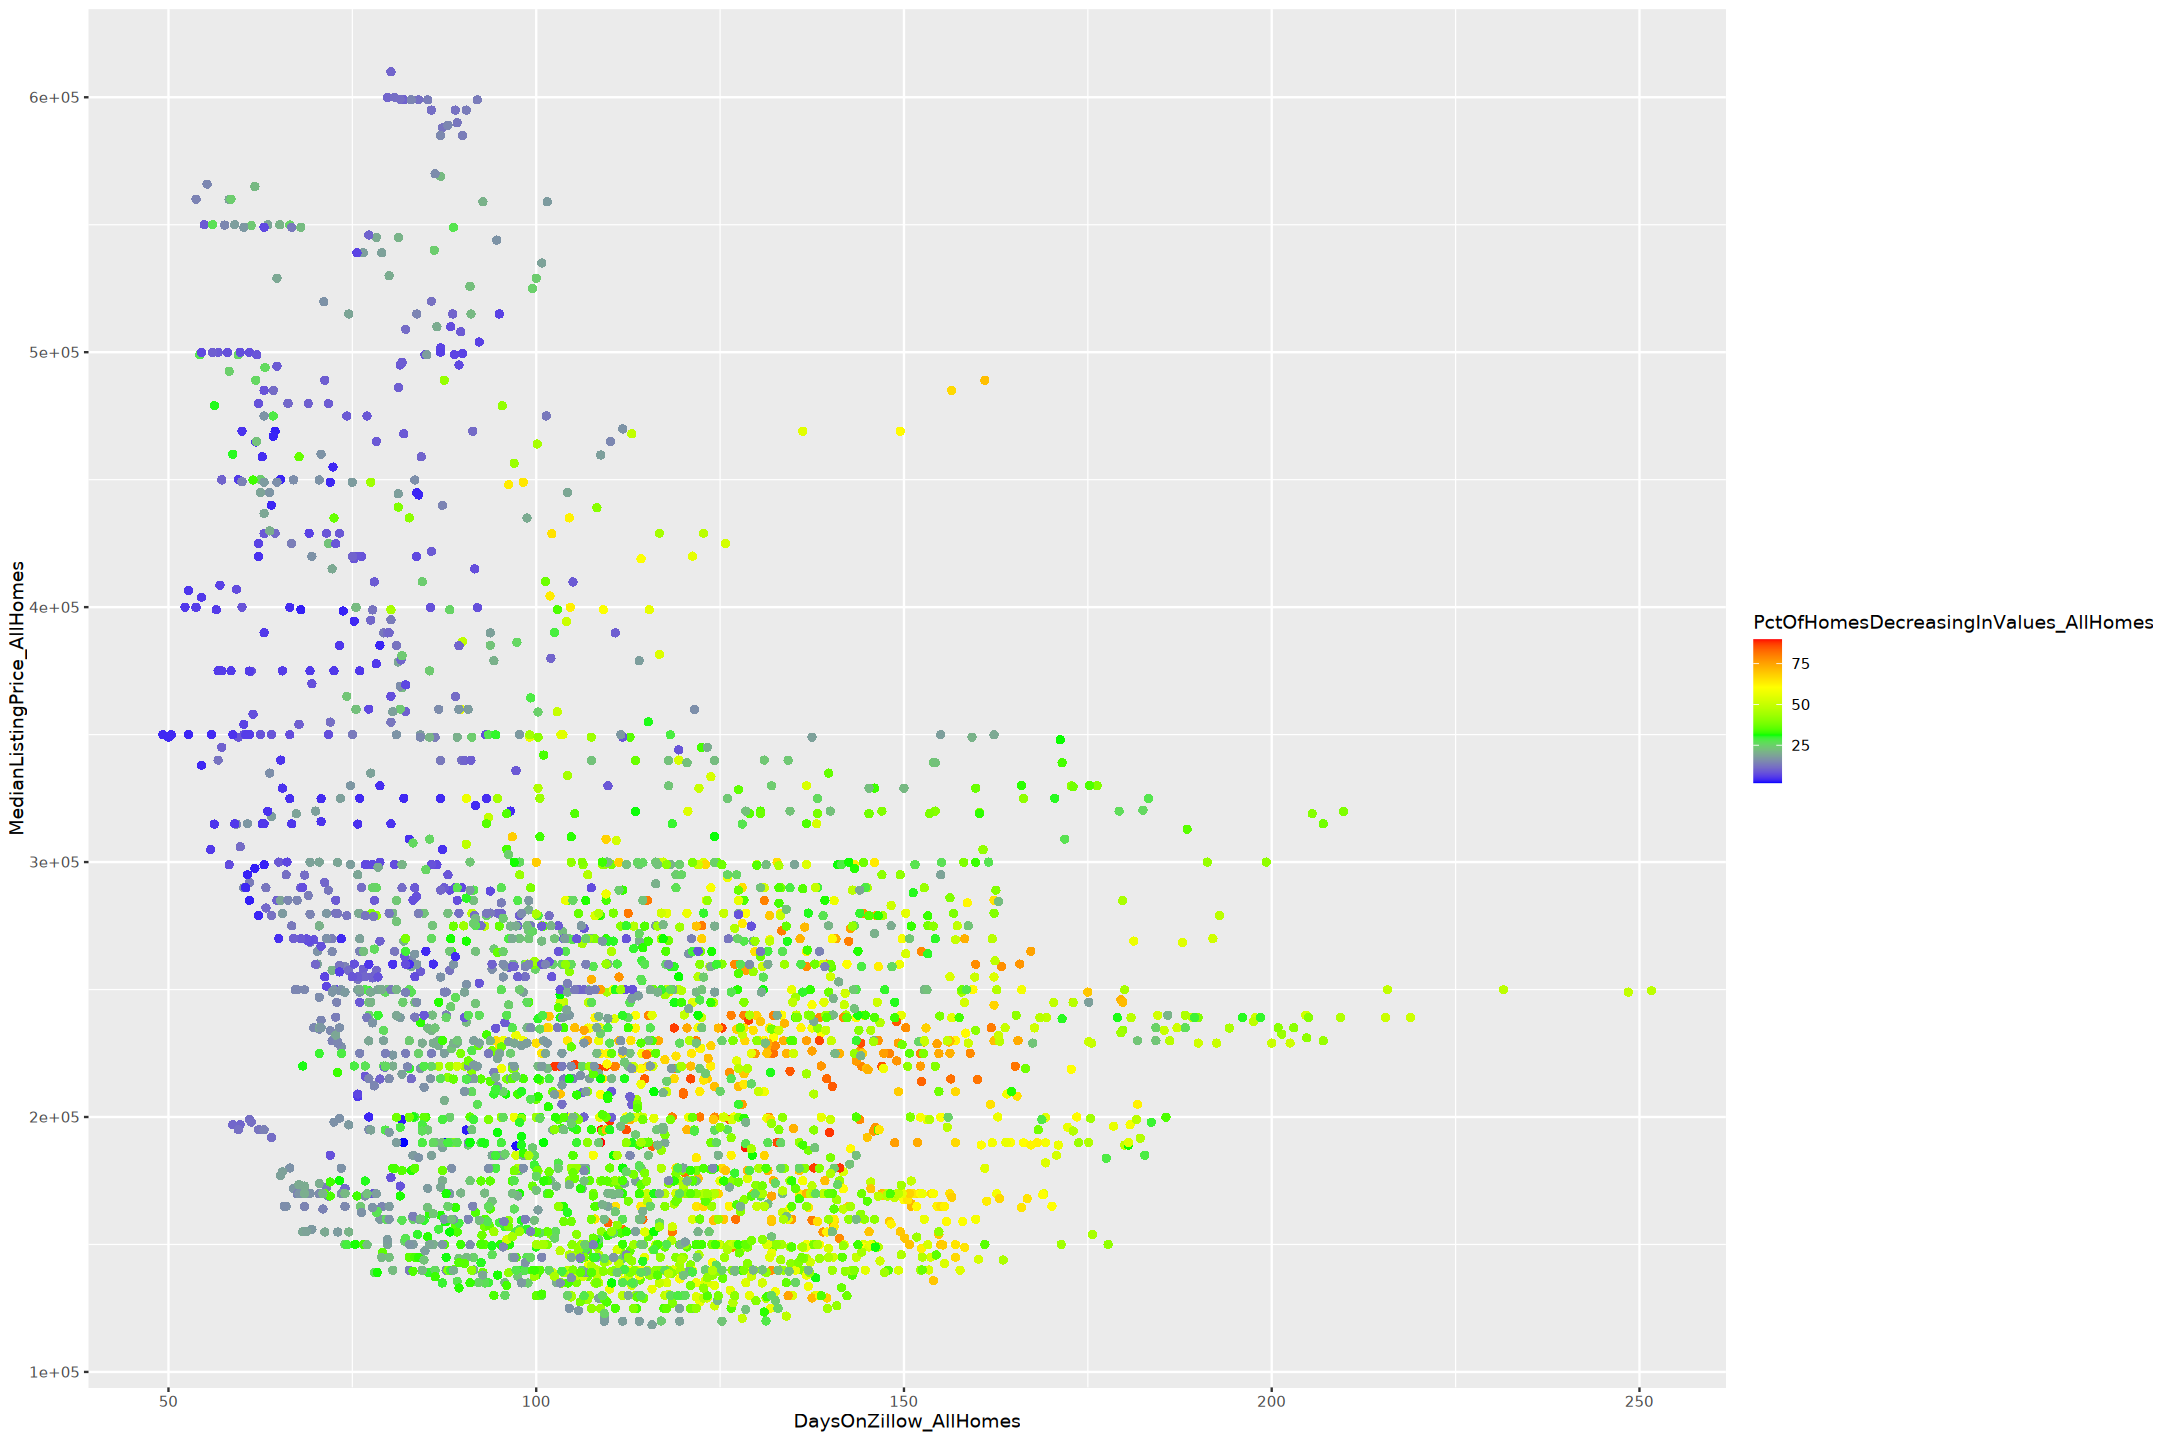

In [166]:
options(repr.plot.width = 18, repr.plot.height = 12)
ggplot(
    zillow_cleaned,
    aes(
        x = DaysOnZillow_AllHomes, 
        y = MedianListingPrice_AllHomes,
        color = PctOfHomesDecreasingInValues_AllHomes
    )
) +
    geom_point(size = 2, shape = 16) +
    scale_color_gradientn(colors = c("blue", "green", "yellow", "red"))
    labs(
        title = "Days on Zillow vs Median Listing Price",
        x = "Days on Zillow (All Homes)",
        y = "Median Listing Price (All Homes)",
        color = "% Homes Decreasing in Value"
    ) +
    theme_minimal()

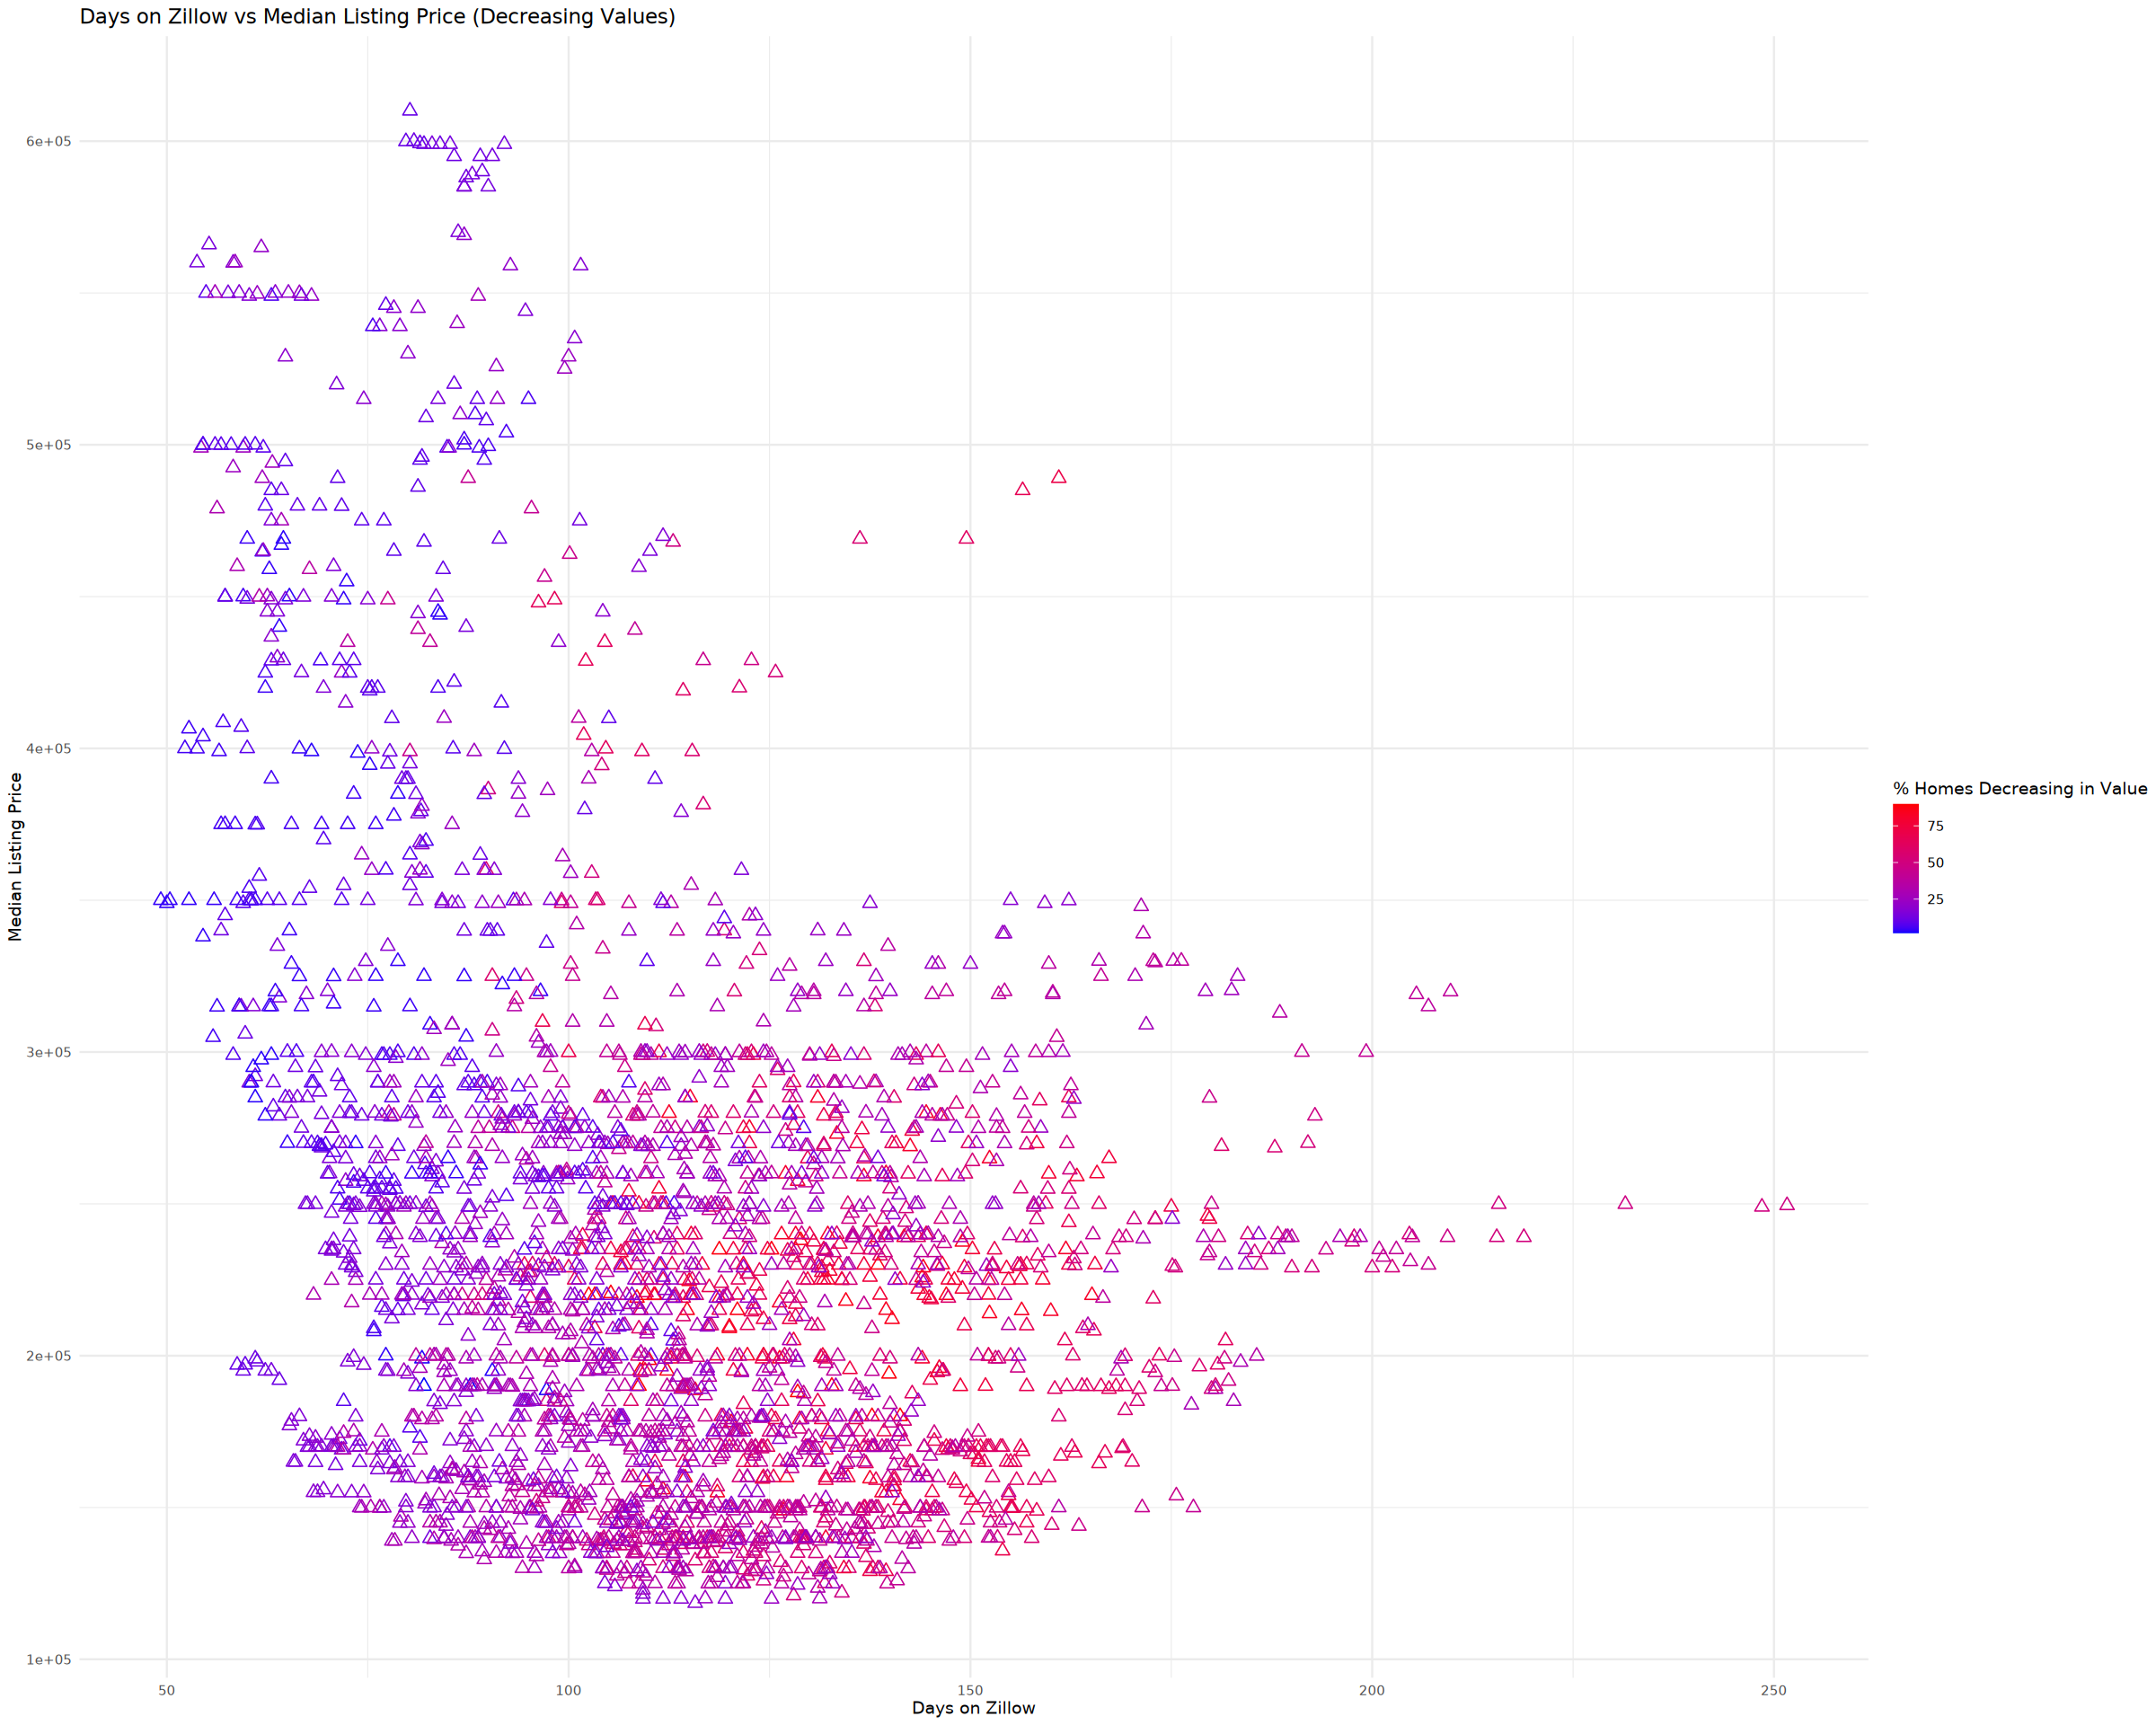

In [167]:
options(repr.plot.width = 20, repr.plot.height = 16)
p1 <- ggplot(
    zillow_cleaned,
    aes(
        x = DaysOnZillow_AllHomes,
        y = MedianListingPrice_AllHomes,
        color = PctOfHomesDecreasingInValues_AllHomes
    )
) +
    geom_point(size = 3, shape = 2) +
    scale_color_gradient(low = "blue", high = "red") +
    labs(
        title = "Days on Zillow vs Median Listing Price (Decreasing Values)",
        x = "Days on Zillow",
        y = "Median Listing Price",
        color = "% Homes Decreasing in Value"
    ) +
    theme_minimal()

print(p1)

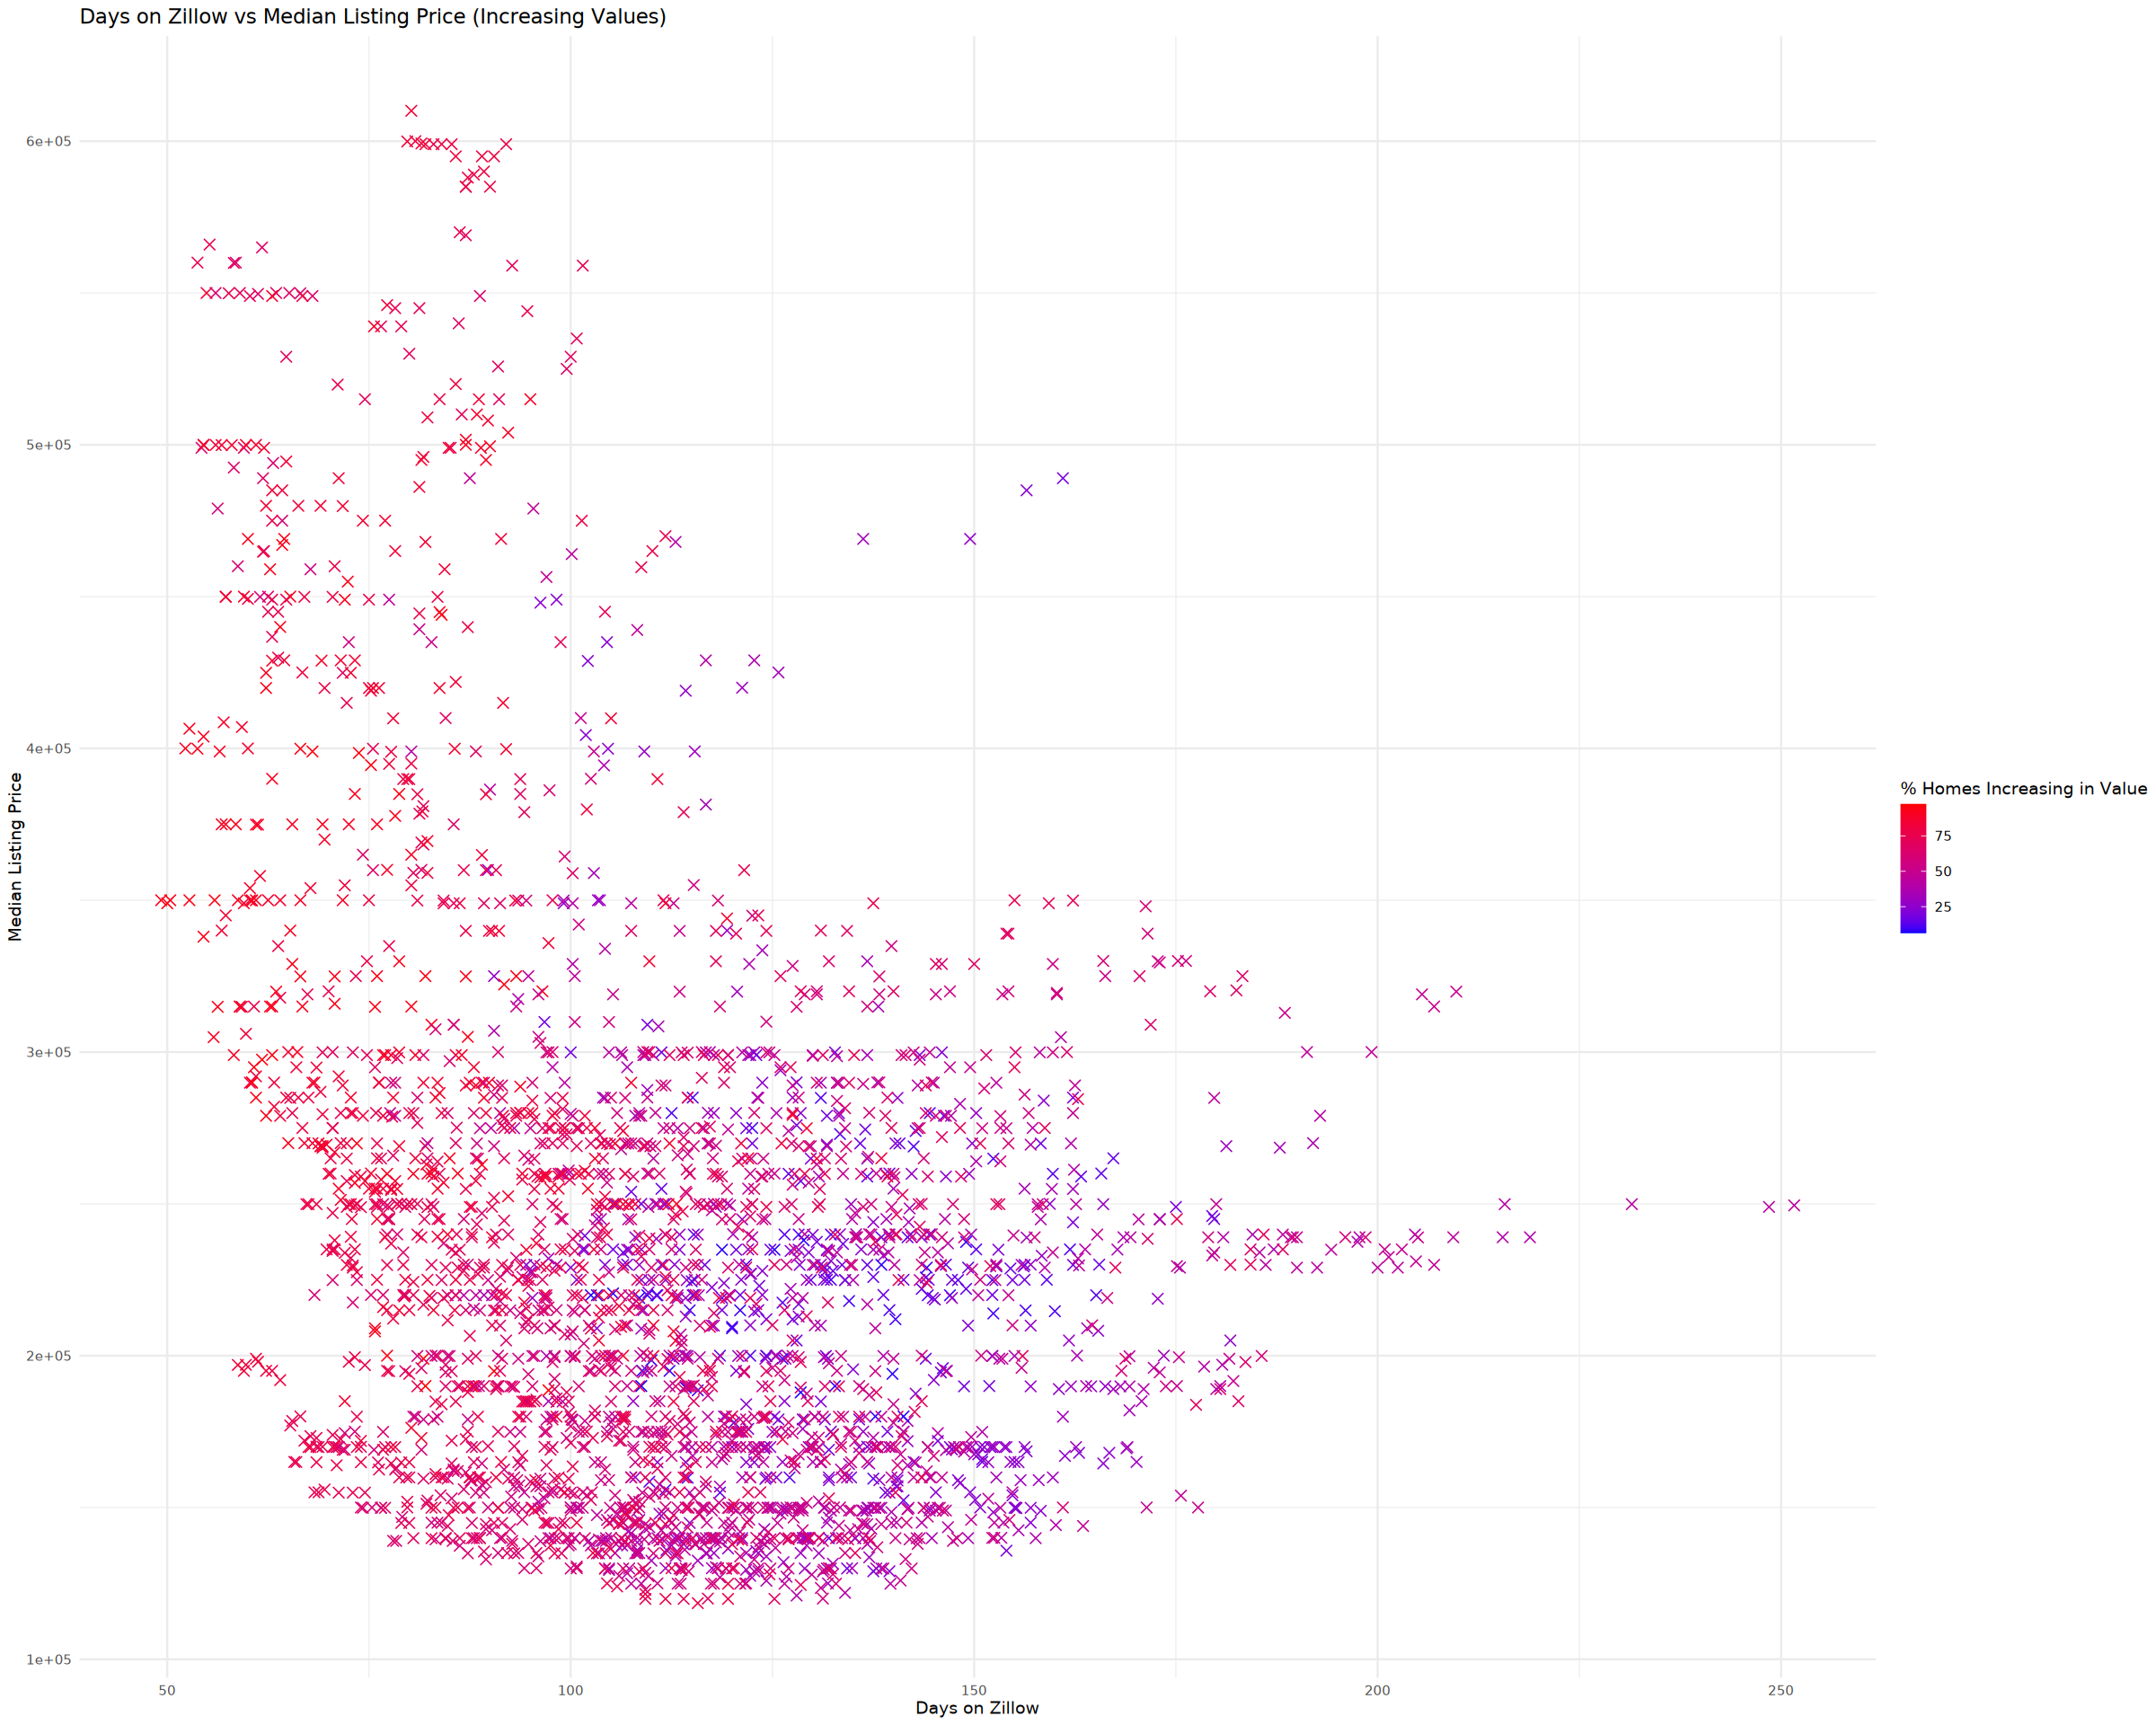

In [168]:
p2 <- ggplot(
    zillow_cleaned,
    aes(
        x = DaysOnZillow_AllHomes,
        y = MedianListingPrice_AllHomes,
        color = PctOfHomesIncreasingInValues_AllHomes
    )
) +
    geom_point(size = 3, shape = 4) +
    scale_color_gradient(low = "blue", high = "red") +
    labs(
        title = "Days on Zillow vs Median Listing Price (Increasing Values)",
        x = "Days on Zillow",
        y = "Median Listing Price",
        color = "% Homes Increasing in Value"
    ) +
    theme_minimal()

print(p2)

In [169]:
p1 <- p1 + geom_smooth(method = "lm", se = FALSE, color = "black")

In [170]:
p2 <- p2 + geom_smooth(method = "lm", se = FALSE, color = "black")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


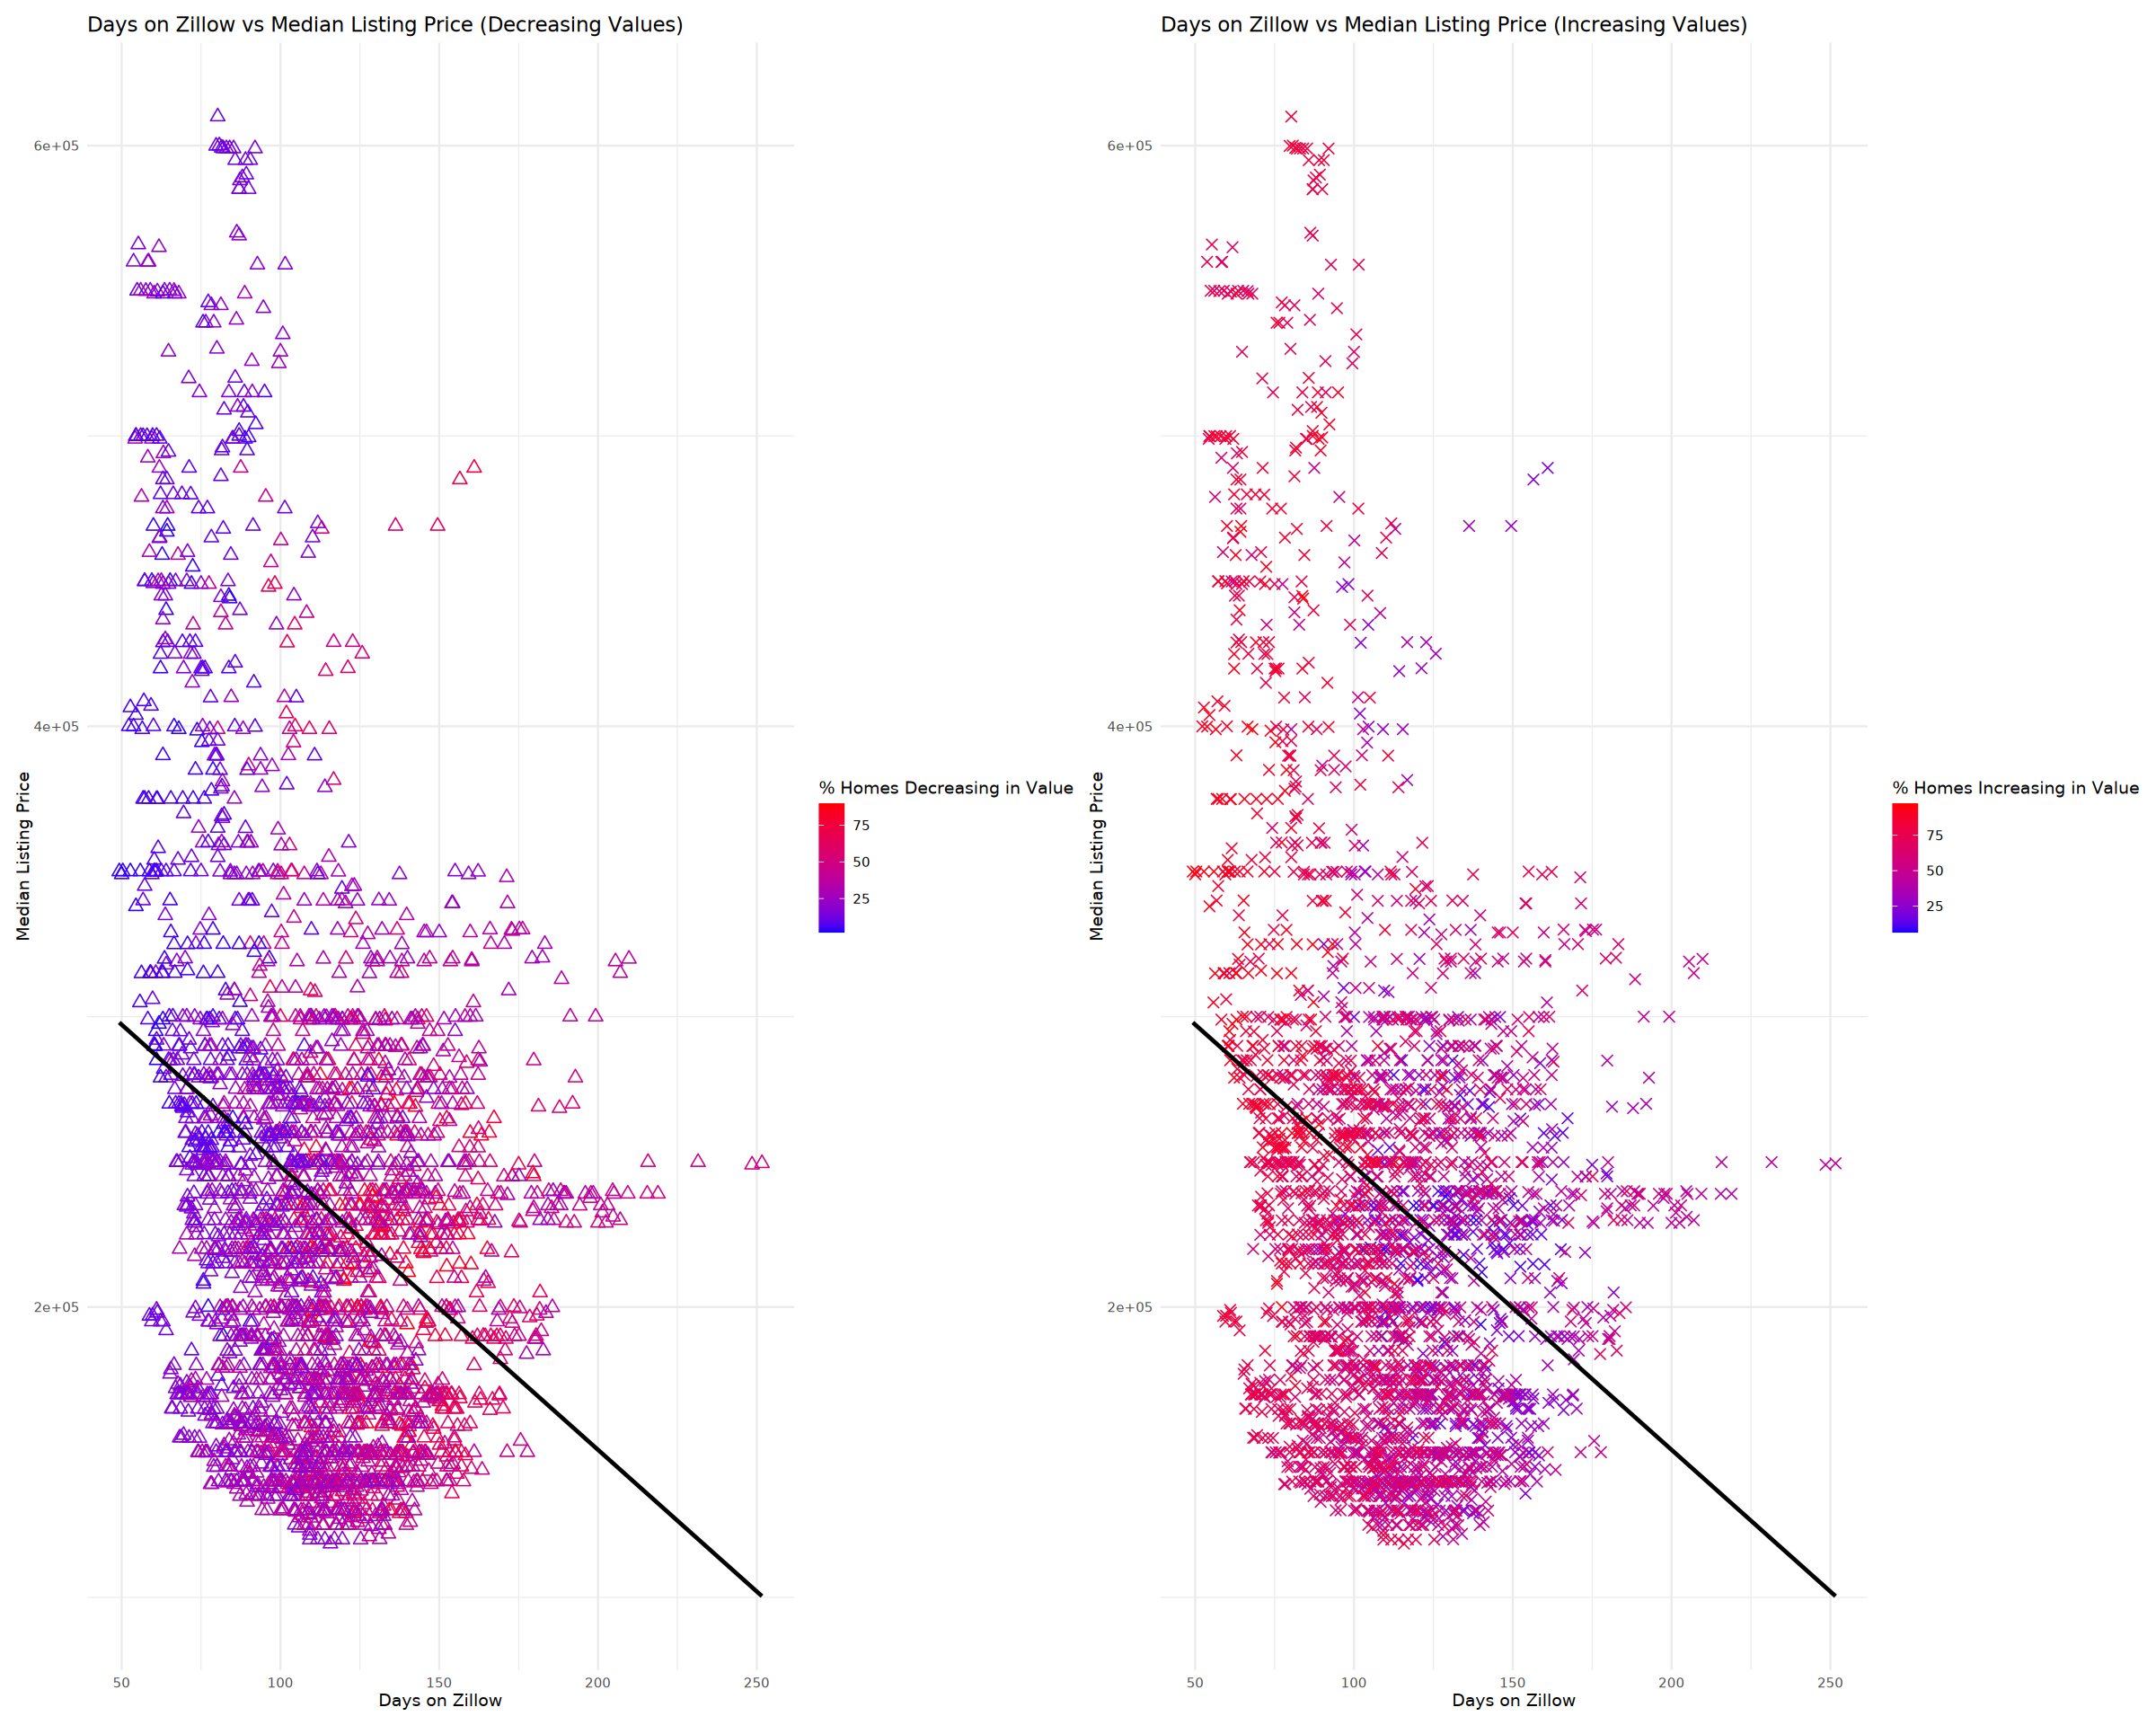

In [171]:
library(patchwork)
p1 + p2

I didn't realize how large and spread out this data would be, and I really like the look of it with the `scale_color_gradient()` function applied. It's very interesting. I also like how you can show more than 2 dimensions by using the gradient.
I like how the trendline for both graphs makes basically zero sense because of how spread out the data is, but I guess I can see that it's roughly decreasing. I still don't think it's the best way to represent the data.
I'm also curious about this error/warning I got when adding the trend lines, `geom_smooth()\` using formula = \'y ~ x\', and if that's just telling me what formula it's defaulting to or if it's a problem.

4.1: I think this is most likely where NA values are in the data, so they can't be grouped into the gradient at all. As seen in 166.

4.2: See 167 and 168. The trendline is added in 171.

4.3: I think that despite many outliers, both graphs show a decent correlation with the idea that the longer a house is listed on Zillow, the lower the median listing price is, and the higher the chance it's decreasing in value is. We can see in the right graph that newer houses on Zillow are generally increasing in value, while older house listings on Zillow are generally decreasing in value.

## Question 5

In [192]:
zillow$Date <- as.Date(zillow$Date)

zillow_cleaned <- zillow %>%
  filter(!is.na(Date),
         !is.na(RegionName),
         !is.na(MedianListingPrice_AllHomes))

In [193]:
selected_regions <- c("Indiana", "Tennessee", "Utah", "NewHampshire")

In [194]:
zillow_grouped_small <- zillow_cleaned %>%
  filter(RegionName %in% selected_regions) %>%
  group_by(Date, RegionName) %>%
  summarize(
    avg_price = mean(MedianListingPrice_AllHomes),
    .groups = "drop"
  )

In [195]:
head(zillow_grouped_small)

Date,RegionName,avg_price
<date>,<chr>,<dbl>
2010-01-31,Indiana,124900
2010-01-31,NewHampshire,249000
2010-01-31,Tennessee,159800
2010-02-28,Indiana,125000
2010-02-28,NewHampshire,239999
2010-02-28,Tennessee,159000


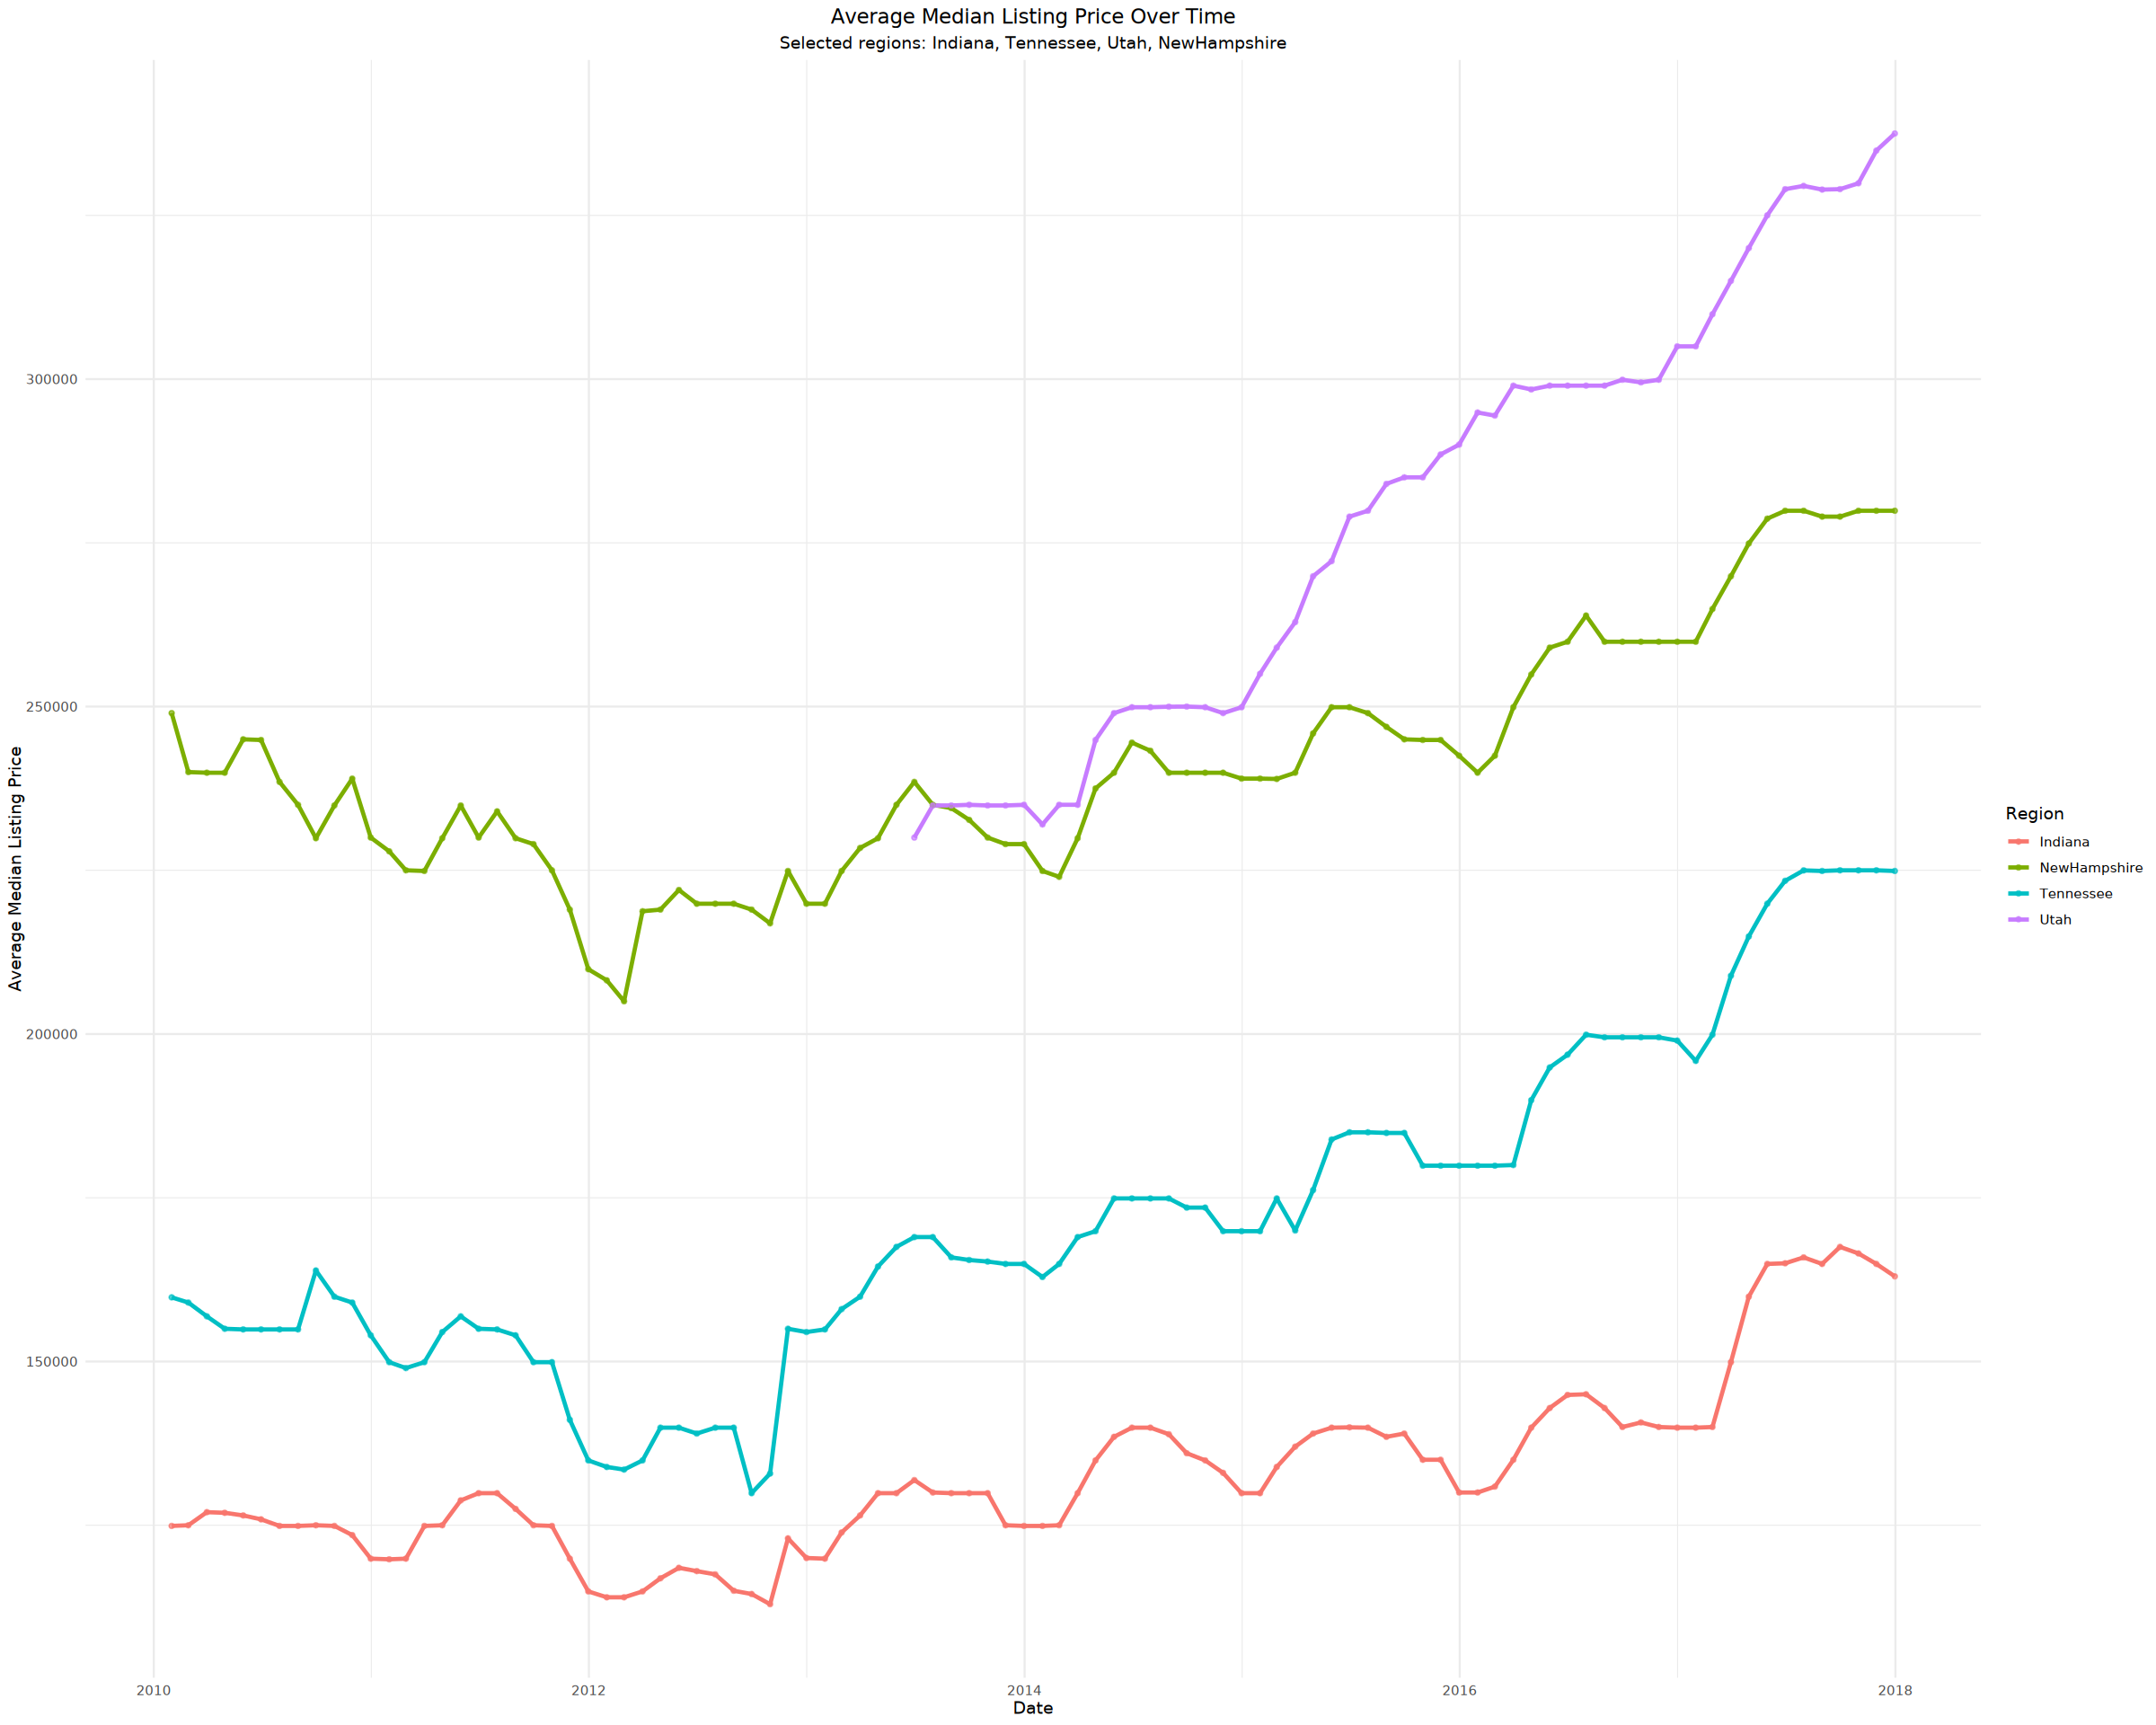

In [196]:
options(repr.plot.width = 20, repr.plot.height = 16)
p <- ggplot(
    zillow_grouped_small,
    aes(
        x = Date,
        y = avg_price,
        color = RegionName,
        group = RegionName
    )
) +
    geom_line(linewidth = 1) +
    geom_point(size = 1, alpha = 0.7) +
    labs(
        title = "Average Median Listing Price Over Time",
        subtitle = "Selected regions: Indiana, Tennessee, Utah, NewHampshire",
        x = "Date",
        y = "Average Median Listing Price",
       color = "Region") +
  theme_minimal() +
  theme(
      plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5)
  )

p

In [ ]:
more_selected_regions <- c("California", "Delaware", "Florida", "Alaska")

zillow_grouped_more <- zillow_cleaned %>%
  filter(RegionName %in% more_selected_regions) %>%
  group_by(Date, RegionName) %>%
  summarise(
    avg_price = mean(MedianListingPrice_AllHomes, na.rm = TRUE),
    .groups = "drop"
  )

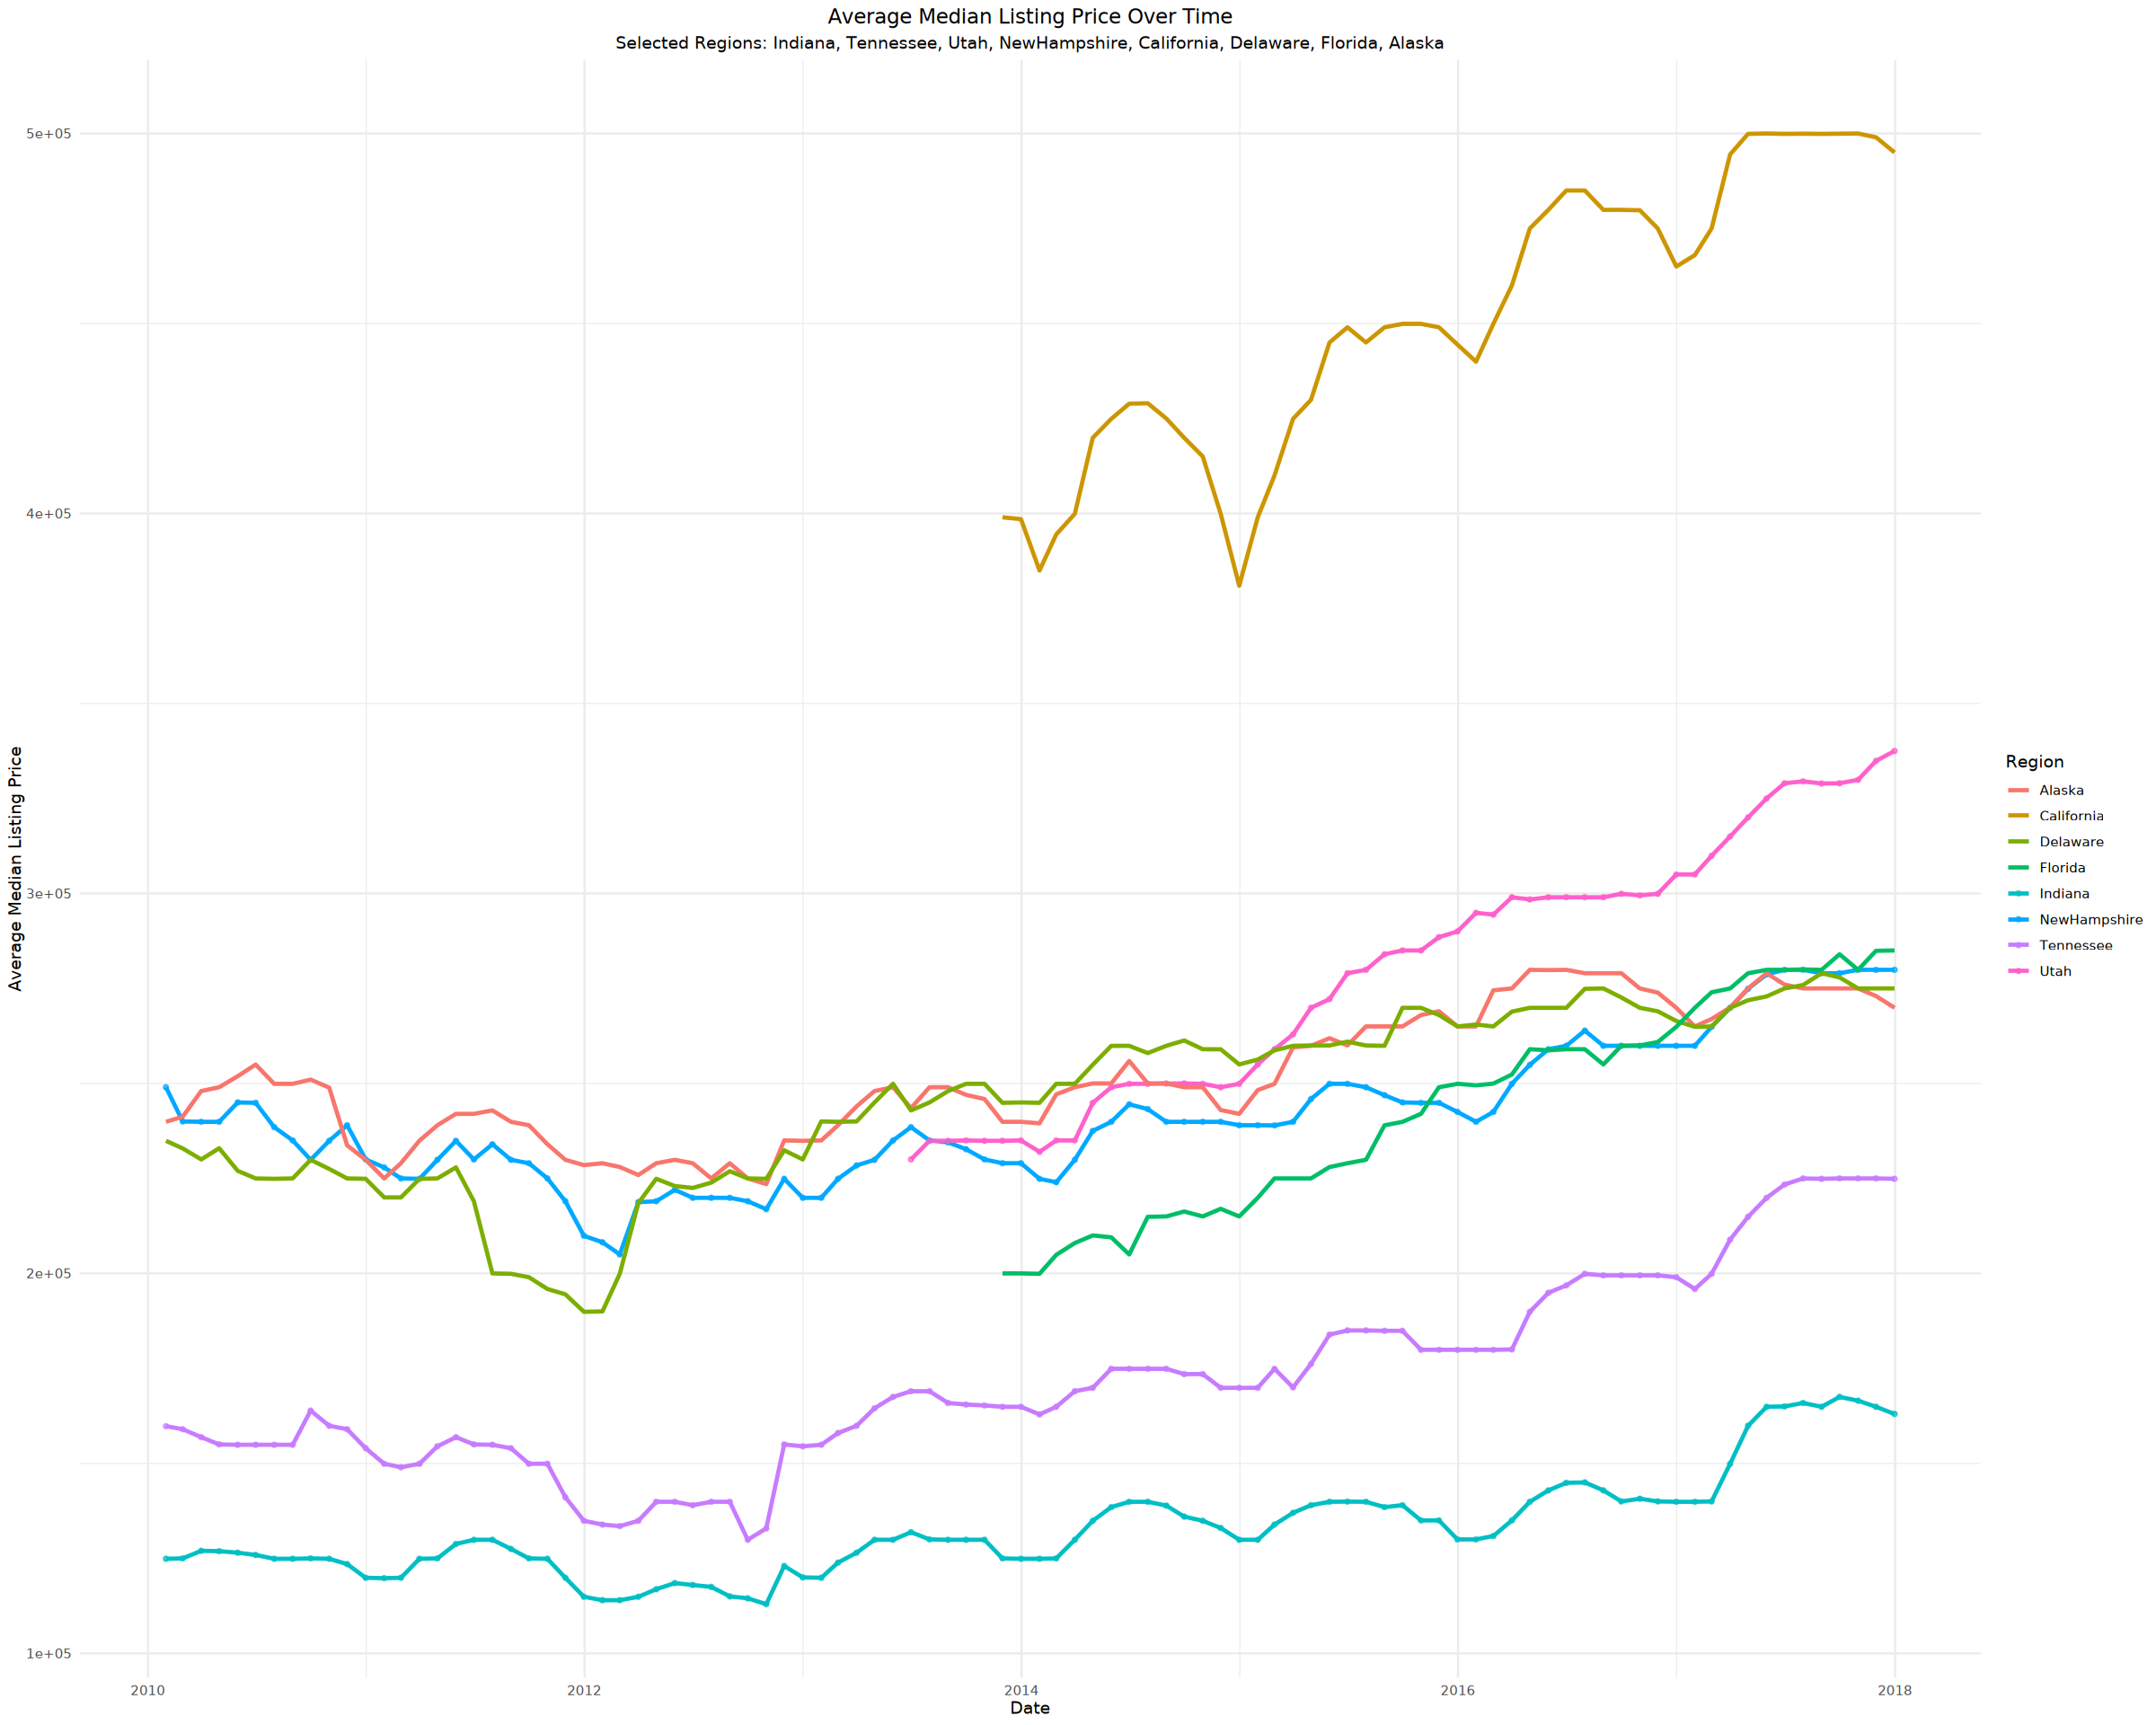

In [203]:
p + geom_line(
    data = zillow_grouped_more,
    aes(
        x = Date,
        y = avg_price,
        color = RegionName,
        group = RegionName
    ),
    size = 1
) + 
labs(
    subtitle = "Selected Regions: Indiana, Tennessee, Utah, NewHampshire, California, Delaware, Florida, Alaska")



5.1: I just used filter from dplyr to remove na values.

5.2: See 196 and 203.

5.3: I think the plot is a pretty cool representation of how across presumably every state given the data, housing prices have gradually increased over time. I also think it's interesting how many of the dips and peaks are reflected across most of the other lines, because of how interconnected our economy is.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
